# Econ 470 HW 4.1
## Claire Hamilton

In [15]:
# Import packages

suppressPackageStartupMessages({
  library(tidyverse)
  library(stargazer)
  library(car)
  library(lmtest)
  library(sandwich)
  library(survival)
})

In [2]:
# Read data

years <- 2009:2019

final_data <- map_dfr(
  years,
  ~ read_csv(paste0("../data/output/data-", .x, ".csv"), show_col_types = FALSE)
)

In [3]:
final.hcris.v1996=read_csv('../data/output/HCRIS_Data_v1996.csv', show_col_types = FALSE)
final.hcris.v2010=read_csv('../data/output/HCRIS_Data_v2010.csv', show_col_types = FALSE)

## create missing variables for columns introduced in v2010 of hcris forms
final.hcris.v1996 = final.hcris.v1996 %>%
  mutate(hvbp_payment=NA, hrrp_payment=NA)

## combine v1996 and v2010 hcris forms, and sort by provider_number/year
final.hcris <- bind_rows(final.hcris.v1996, final.hcris.v2010) %>%
  mutate(
    fy_end = mdy(fy_end),
    fy_start = mdy(fy_start),
    date_processed = mdy(date_processed),
    date_created = mdy(date_created),
    tot_discounts = abs(tot_discounts),
    hrrp_payment = abs(hrrp_payment)
  ) %>%
  mutate(fyear = year(fy_end)) %>%
  arrange(provider_number, fyear) %>%
  select(-any_of("year"))

In [4]:
# glimpse(final.hcris)

## Question 1

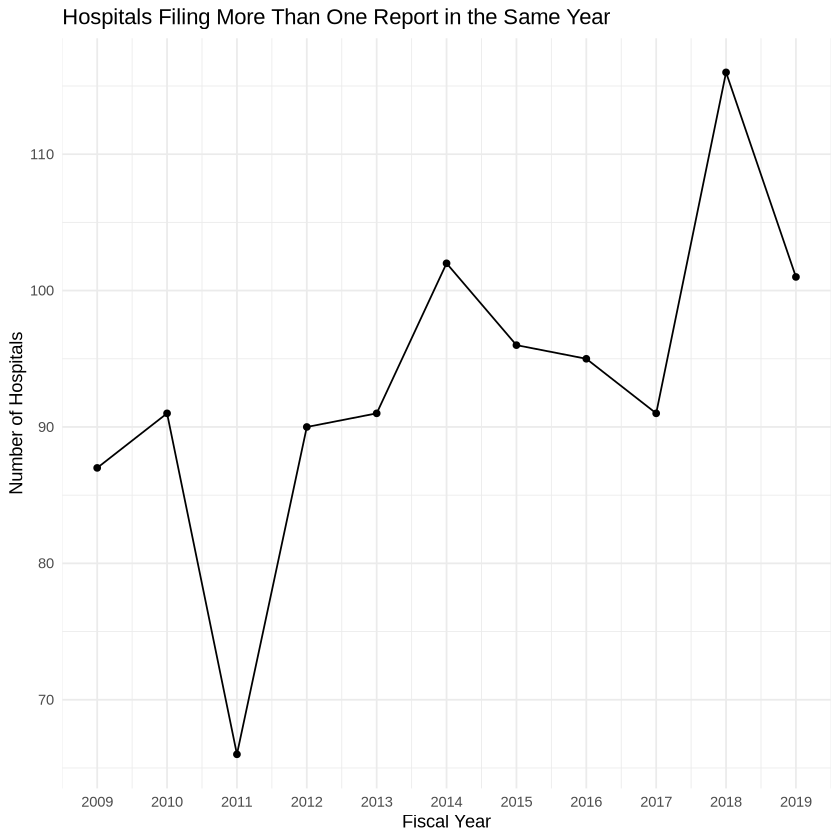

In [16]:
# Question 1

hospitals_per_year <- final.hcris %>%
  filter(fyear >= 2009, fyear <= 2019) %>%
  group_by(fyear, provider_number) %>%
  summarize(n_reports = n(), .groups = "drop") %>%
  filter(n_reports > 1) %>%
  count(fyear, name = "n_hospitals") %>%
  complete(fyear = 2009:2019, fill = list(n_hospitals = 0))

ggplot(hospitals_per_year, aes(x = fyear, y = n_hospitals)) +
  geom_line() +
  geom_point() +
  scale_x_continuous(breaks = 2009:2019) +
  labs(
    title = "Hospitals Filing More Than One Report in the Same Year",
    x = "Fiscal Year",
    y = "Number of Hospitals"
  ) +
  theme_minimal()

## Question 2

In [6]:
# Question 2

n_hospitals <- final_data %>%
  summarize(n = n_distinct(provider_number))

n_hospitals

n
<int>
6893


After removing/combining multiple reports, 6,893 unique hospital IDs exist in the data.

## Question 3

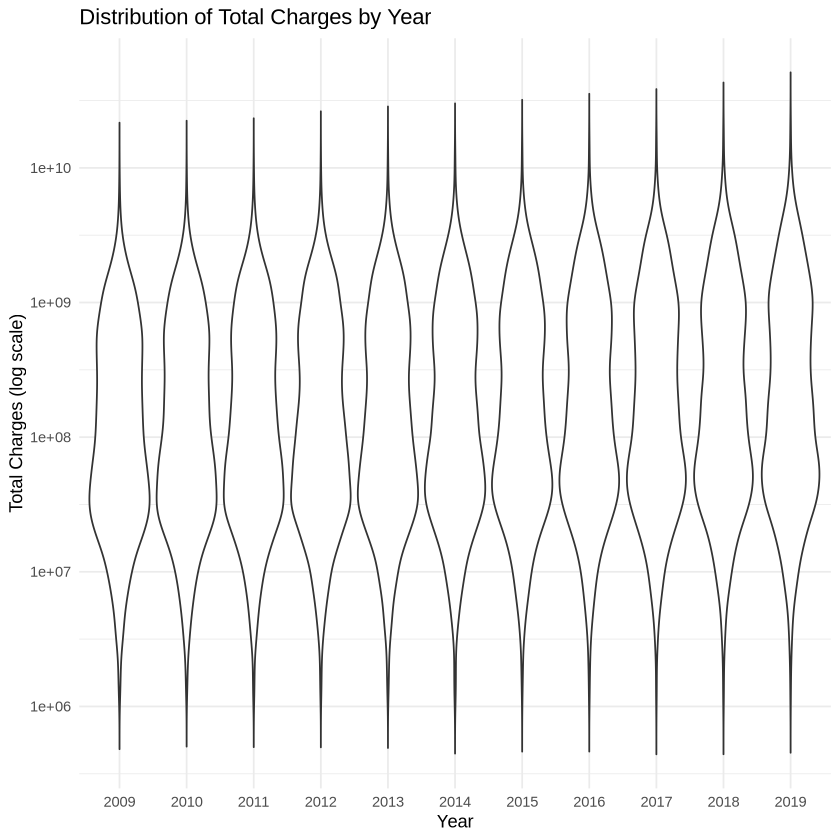

In [18]:
# Question 3

final_data %>%
  filter(
    year >= 2009, year <= 2019,
    !is.na(tot_charges),
    tot_charges > 1e6 
  ) %>%
  ggplot(aes(x = factor(year), y = tot_charges)) +
  geom_violin(trim = FALSE) +
  scale_y_log10() +
  labs(
    title = "Distribution of Total Charges by Year",
    x = "Year",
    y = "Total Charges (log scale)"
  ) +
  theme_minimal()

## Question 4

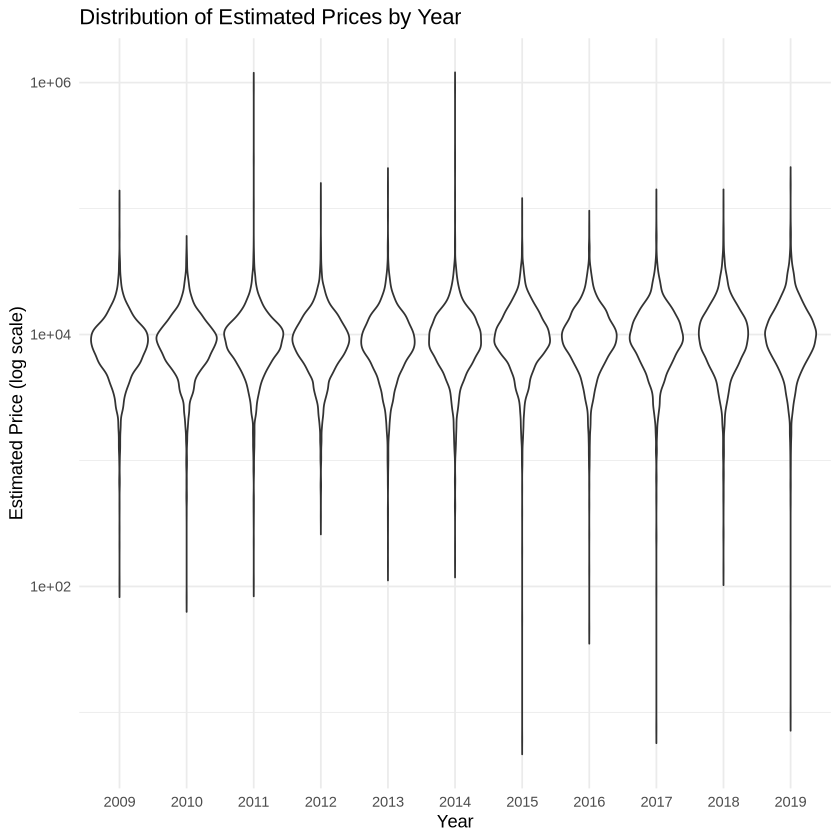

In [19]:
# Question 4

final_data %>%
  mutate(
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(
    year >= 2009, year <= 2019,
    !is.na(price),
    price > 0,               
    price_denom > 0,           
    price < 1e6           
  ) %>%
  ggplot(aes(x = factor(year), y = price)) +
  geom_violin(trim = FALSE) +
  scale_y_log10() +
  labs(
    title = "Distribution of Estimated Prices by Year",
    x = "Year",
    y = "Estimated Price (log scale)"
  ) +
  theme_minimal()

## Question 5

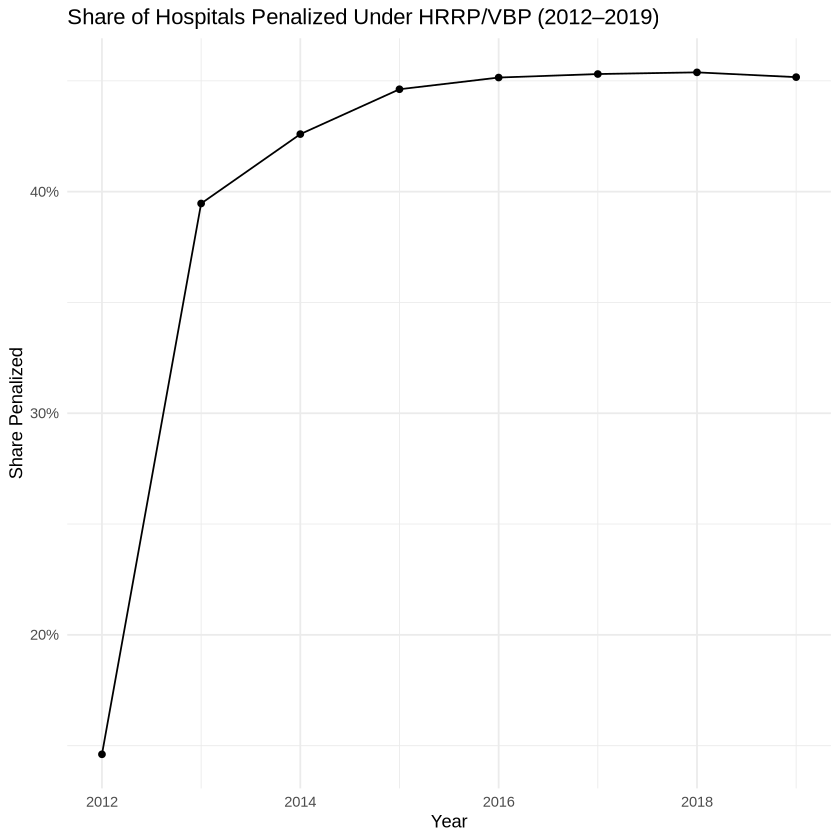

In [20]:
penalty_share <- final_data %>%
  filter(year >= 2012, year <= 2019) %>%
  mutate(
    hrrp_payment = if_else(is.na(hrrp_payment), 0, hrrp_payment),
    hvbp_payment = if_else(is.na(hvbp_payment), 0, hvbp_payment),
    penalized = if_else(hrrp_payment > 0 | hvbp_payment < 0, 1, 0)
  ) %>%
  group_by(year) %>%
  summarize(
    share_penalized = mean(penalized),
    .groups = "drop"
  )

ggplot(penalty_share, aes(x = year, y = share_penalized)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Share of Hospitals Penalized Under HRRP/VBP (2012–2019)",
    x = "Year",
    y = "Share Penalized"
  ) +
  theme_minimal()

# Estimate ATEs

## Question 6

In [22]:
# Question 6

# Estimated price at hospital-yr level
analysis_data <- final_data %>%
  mutate(
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom,
    hrrp_payment = if_else(is.na(hrrp_payment), 0, hrrp_payment),
    hvbp_payment = if_else(is.na(hvbp_payment), 0, hvbp_payment)
  ) %>%
  filter(
    year >= 2009, year <= 2014,
    !is.na(provider_number),
    !is.na(price),
    price_denom > 0,
    price > 0
  )

# Price change from 2011-2014
price_change_df <- analysis_data %>%
  filter(year %in% c(2011, 2014)) %>%
  select(provider_number, year, price) %>%
  distinct(provider_number, year, .keep_all = TRUE) %>%
  pivot_wider(
    names_from = year,
    values_from = price,
    names_prefix = "price_"
  ) %>%
  filter(!is.na(price_2011), !is.na(price_2014)) %>%
  mutate(
    price_change = price_2014 - price_2011
  )

# 2012 net penalty
penalty_2012_df <- analysis_data %>%
  filter(year == 2012) %>%
  transmute(
    provider_number,
    net_penalty_2012 = hrrp_payment - hvbp_payment
  ) %>%
  distinct(provider_number, .keep_all = TRUE)

# Pre-penalty controls 
pre_controls_df <- analysis_data %>%
  filter(year %in% 2009:2011) %>%
  group_by(provider_number) %>%
  summarize(
    mean_beds_pre = mean(beds, na.rm = TRUE),
    mean_mcaid_discharges_pre = mean(mcaid_discharges, na.rm = TRUE),
    mean_mcare_discharges_pre = mean(mcare_discharges, na.rm = TRUE),
    .groups = "drop"
  )

# Merge 
reg_df <- price_change_df %>%
  inner_join(penalty_2012_df, by = "provider_number") %>%
  inner_join(pre_controls_df, by = "provider_number") %>%
  filter(
    !is.na(net_penalty_2012),
    !is.na(mean_beds_pre),
    !is.na(mean_mcaid_discharges_pre)
  )

# OLS 
m1 <- lm(price_change ~ net_penalty_2012, data = reg_df)

m2 <- lm(
  price_change ~ net_penalty_2012 + mean_beds_pre,
  data = reg_df
)

m3 <- lm(
  price_change ~ net_penalty_2012 + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# Table

stargazer(
  m1, m2, m3,
  type = "text", 
  title = "OLS Estimates of the Effect of 2012 Net Penalties on Price Changes (2011–2014)",
  column.labels = c("Baseline", "Baseline + Bed Size", "Baseline + Bed Size + Medicaid"),
  dep.var.labels = "Price Change",
  covariate.labels = c(
    "Net Penalty (2012)",
    "Mean Beds (2009–2011)",
    "Mean Medicaid Discharges (2009–2011)"
  ),
  digits = 3,
  omit.stat = c("f", "ser")  
)


OLS Estimates of the Effect of 2012 Net Penalties on Price Changes (2011–2014)
                                                         Dependent variable:                     
                                     ------------------------------------------------------------
                                                             Price Change                        
                                     Baseline  Baseline + Bed Size Baseline + Bed Size + Medicaid
                                        (1)            (2)                      (3)              
-------------------------------------------------------------------------------------------------
Net Penalty (2012)                     0.003          0.003                    0.002             
                                      (0.009)        (0.009)                  (0.010)            
                                                                                                 
Mean Beds (2009–2011)                 

There is no statistically significant effect of net penalties on price changes for any of the models. 

## Question 7

`geom_smooth()` using formula = 'y ~ x'


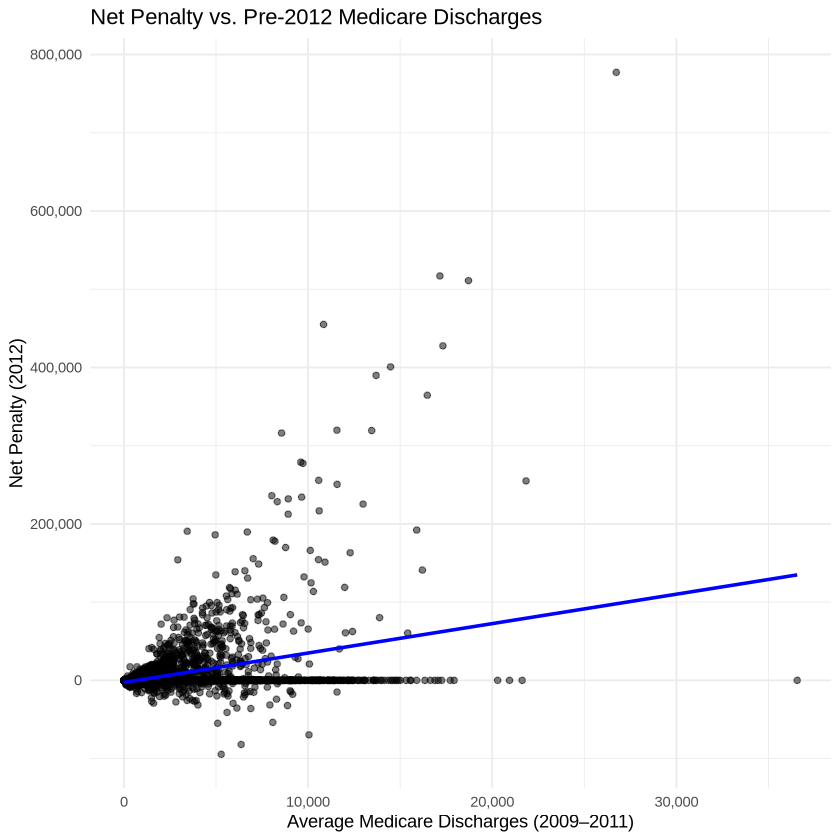

In [12]:
# Create dataset 
scatter_df <- final_data %>%
  mutate(
    hrrp_payment = if_else(is.na(hrrp_payment), 0, hrrp_payment),
    hvbp_payment = if_else(is.na(hvbp_payment), 0, hvbp_payment)
  ) %>%
  filter(year >= 2009, year <= 2012) %>%
  group_by(provider_number) %>%
  summarize(
    mean_mcare_discharges_pre = mean(mcare_discharges[year %in% 2009:2011], na.rm = TRUE),
    net_penalty_2012 = (hrrp_payment[year == 2012] - hvbp_payment[year == 2012])[1],
    .groups = "drop"
  ) %>%
  filter(!is.na(mean_mcare_discharges_pre), !is.na(net_penalty_2012))

# Plot
ggplot(scatter_df, aes(x = mean_mcare_discharges_pre, y = net_penalty_2012)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  scale_y_continuous(labels = scales::comma) +
  scale_x_continuous(labels = scales::comma) +
  labs(
    title = "Net Penalty vs. Pre-2012 Medicare Discharges",
    x = "Average Medicare Discharges (2009–2011)",
    y = "Net Penalty (2012)"
  ) +
  theme_minimal()

## Question 8

In [13]:
# First stage regressions
fs1 <- lm(net_penalty_2012 ~ mean_mcare_discharges_pre, data = reg_df)

fs2 <- lm(
  net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre,
  data = reg_df
)

fs3 <- lm(
  net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# Reduced form regressions
rf1 <- lm(price_change ~ mean_mcare_discharges_pre, data = reg_df)

rf2 <- lm(
  price_change ~ mean_mcare_discharges_pre + mean_beds_pre,
  data = reg_df
)

rf3 <- lm(
  price_change ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# Table
stargazer(
  fs1, fs2, fs3, rf1, rf2, rf3,
  type = "text",
  title = "First Stage and Reduced Form Estimates",
  column.labels = c(
    "FS Baseline", "FS + Beds", "FS + Beds + Medicaid",
    "RF Baseline", "RF + Beds", "RF + Beds + Medicaid"
  ),
  dep.var.labels = c("Net Penalty (2012)", "Price Change (2011–2014)"),
  covariate.labels = c(
    "Avg Medicare Discharges (2009–2011)",
    "Mean Beds (2009–2011)",
    "Mean Medicaid Discharges (2009–2011)"
  ),
  digits = 3,
  omit.stat = c("f", "ser")
)


First Stage and Reduced Form Estimates
                                                                         Dependent variable:                                    
                                     -------------------------------------------------------------------------------------------
                                                    Net Penalty (2012)                         Price Change (2011–2014)         
                                      FS Baseline    FS + Beds   FS + Beds + Medicaid RF Baseline RF + Beds RF + Beds + Medicaid
                                          (1)           (2)              (3)              (4)        (5)            (6)         
--------------------------------------------------------------------------------------------------------------------------------
Avg Medicare Discharges (2009–2011)    4.181***      4.182***          4.591***         0.275**    0.271**        0.296**       
                                        (0.237)       (0.

The first-stage results show a statistically significant positive relationship between pre-2012 Medicare discharges and 2012 net penalties. The reduced-form estimates show that higher Medicare discharges is associated with increased price growth from 2011 to 2014.

## Question 9

In [14]:
# IV regressions
iv1 <- ivreg(
  price_change ~ net_penalty_2012 |
    mean_mcare_discharges_pre,
  data = reg_df
)

iv2 <- ivreg(
  price_change ~ net_penalty_2012 + mean_beds_pre |
    mean_mcare_discharges_pre + mean_beds_pre,
  data = reg_df
)

iv3 <- ivreg(
  price_change ~ net_penalty_2012 + mean_beds_pre + mean_mcaid_discharges_pre |
    mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre,
  data = reg_df
)

# Table
stargazer(
  iv1, iv2, iv3,
  type = "text",
  title = "IV Estimates of the Effect of Net Penalties on Price Changes (2011–2014)",
  column.labels = c("Baseline", "Baseline + Beds", "Baseline + Beds + Medicaid"),
  dep.var.labels = "Price Change",
  covariate.labels = c(
    "Net Penalty (2012)",
    "Mean Beds (2009–2011)",
    "Mean Medicaid Discharges (2009–2011)"
  ),
  digits = 3,
  omit.stat = c("f", "ser")
)


IV Estimates of the Effect of Net Penalties on Price Changes (2011–2014)
                                                     Dependent variable:                 
                                     ----------------------------------------------------
                                                         Price Change                    
                                     Baseline  Baseline + Beds Baseline + Beds + Medicaid
                                        (1)          (2)                  (3)            
-----------------------------------------------------------------------------------------
Net Penalty (2012)                    0.066**      0.065**              0.065**          
                                      (0.028)      (0.029)              (0.030)          
                                                                                         
Mean Beds (2009–2011)                               0.063                0.063           
                          

The IV estimates indicate that higher net penalties lead to increases in hospital price growth, and the results are statistically significant. Compared to OLS, the IV estimates are smaller in magnitude. This could suggest that OLS may overstate the effect due to endogeneity that IV helps to correct for.

## Question 10

The IV estimate provides a Local ATE, which shows the effect of penalties on price changes for hospitals that have penalties that are influenced by their pre-2012 Medicare discharges. The LATE may differ from the overall ATE because it only applies to hospitals whose penalty status is affected by the instrument, rather than all hospitals. Thus, it may not generalize to hospitals with very low or very high Medicare discharges.